# [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)

In [ ]:
# Imports
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
import numpy as np
import random
import os
import pickle
import urllib.request
import tarfile
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F

 **Download and Extract CIFAR-10
(Original Dataset is Domain 1)**

File organization format: Data -> Train/Validation/Test -> Domain -> Class


In [ ]:
# Configuration
CIFAR10_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = "/content/cifar10_data"
PNG_DIR  = "/content/cifar10_pngs"
IMAGES_PER_CLASS = 5000 # We can change if we want to reduce compute time
BATCH_SIZE = 64
SPLIT = (0.70, 0.10, 0.20)    # We can change depending on desired split
SEED = 42

CIFAR10_CLASSES = [ "airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# ImageNet based
NORMALIZE = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])

# Gaussian noise transform
class AddGaussianNoise:
  """
  Adds Gaussian noise to a tensor after ToTensor().
  """
  def __init__(self, mean: float = 0.0, std: float = 0.1):
    self.mean = mean
    self.std  = std

  def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
    return tensor + torch.randn_like(tensor) * self.std + self.mean

  def __repr__(self):
    return f"AddGaussianNoise(mean={self.mean}, std={self.std})"

# Helper functions
def download_cifar10(data_dir: str = DATA_DIR) -> str:
  """
  Downloads the CIFAR-10 dataset and extracts it to the given directory.
  """
  os.makedirs(data_dir, exist_ok=True)
  tar_path = os.path.join(data_dir, "cifar-10-python.tar.gz")

  if not os.path.exists(tar_path):
    print("Downloading CIFAR-10 …")
    urllib.request.urlretrieve(CIFAR10_URL, tar_path)
    print("Download complete.")

  extract_path = os.path.join(data_dir, "cifar-10-batches-py")
  if not os.path.exists(extract_path):
    print("Extracting …")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(data_dir)
    print("Extraction complete.")

  return extract_path


def load_cifar10_raw(extract_path: str):
  """
  Loads the CIFAR-10 dataset from the given directory.
  """
  train_images, train_labels = [], []
  test_images, test_labels = [], []

  # 5 training batches
  for i in range(1, 6):
    fpath = os.path.join(extract_path, f"data_batch_{i}")
    with open(fpath, "rb") as f:
        entry = pickle.load(f, encoding="bytes")
    imgs = entry[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    train_images.append(imgs)
    train_labels.extend(entry[b"labels"])

  # 1 test batch
  fpath = os.path.join(extract_path, "test_batch")
  with open(fpath, "rb") as f:
    entry = pickle.load(f, encoding="bytes")
  imgs = entry[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
  test_images.append(imgs)
  test_labels.extend(entry[b"labels"])

  train_images = np.concatenate(train_images, axis=0)
  test_images = np.concatenate(test_images, axis=0)

  print(f"Train set: {train_images.shape} | Test set: {test_images.shape}")
  return (train_images, np.array(train_labels), test_images, np.array(test_labels))

def save_pngs(train_images, train_labels, test_images,  test_labels, png_dir: str = PNG_DIR, images_per_class: int = IMAGES_PER_CLASS, split: tuple = SPLIT, seed: int = SEED) -> None:
  """
  Saves images as <png_dir>/<class_name>/<index>.png.
  """
  test_per_class = min(images_per_class, 1000)
  rng = np.random.default_rng(seed)

  print(f"Splitting and saving train/val PNGs (up to {images_per_class} per class) ...")

  # Collect indices per class
  class_indices = {i: [] for i in range(10)}
  for idx, lbl in enumerate(train_labels):
    if len(class_indices[int(lbl)]) < images_per_class:
      class_indices[int(lbl)].append(idx)

  train_counts = {i: 0 for i in range(10)}
  val_counts = {i: 0 for i in range(10)}

  for lbl, indices in class_indices.items():
    indices = np.array(indices)
    rng.shuffle(indices)

    n = len(indices)
    n_tr = int(n * split[0])
    n_val = int(n * split[1])

    train_indices = indices[:n_tr]
    val_indices = indices[n_tr:n_tr + n_val]

    for i, idx in enumerate(train_indices):
      class_dir = os.path.join(png_dir, "train", CIFAR10_CLASSES[lbl])
      os.makedirs(class_dir, exist_ok=True)
      Image.fromarray(train_images[idx]).save(os.path.join(class_dir, f"{i:05d}.png"))
      train_counts[lbl] += 1

    for i, idx in enumerate(val_indices):
      class_dir = os.path.join(png_dir, "val", CIFAR10_CLASSES[lbl])
      os.makedirs(class_dir, exist_ok=True)
      Image.fromarray(train_images[idx]).save(os.path.join(class_dir, f"{i:05d}.png"))
      val_counts[lbl] += 1

  print(f"Saved {sum(train_counts.values())} train PNGs")
  print(f"Saved {sum(val_counts.values())} val PNGs")

  print(f"Saving test PNGs (up to {test_per_class} per class) ...")
  test_counts = {i: 0 for i in range(10)}

  for img, lbl in zip(test_images, test_labels):
    lbl = int(lbl)
    if test_counts[lbl] >= test_per_class:
      continue
    class_dir = os.path.join(png_dir, "test", CIFAR10_CLASSES[lbl])
    os.makedirs(class_dir, exist_ok=True)
    Image.fromarray(img).save(
      os.path.join(class_dir, f"{test_counts[lbl]:05d}.png")
    )
    test_counts[lbl] += 1

    if all(v >= test_per_class for v in test_counts.values()):
        break

  print(f"  Saved {sum(test_counts.values())} test PNGs")

def load_splits(png_dir: str = PNG_DIR) -> dict:
  """
  Reads file paths directly from train / val / test folders.
  Returns:
    { "train": [(path, label), ...],
      "val":   [...],
      "test":  [...] }
  """
  splits = {"train": [], "val": [], "test": []}

  for split_name in ["train", "val", "test"]:
    for lbl, cls in enumerate(CIFAR10_CLASSES):
      cls_dir = os.path.join(png_dir, split_name, cls)
      files = sorted([os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.endswith(".png")
      ])
      splits[split_name].extend([(p, lbl) for p in files])

  print(f"Loaded splits -> train:{len(splits['train'])} "f"val:{len(splits['val'])}  test:{len(splits['test'])}")
  return splits

Rotation should only be done in multiples of 90 degress

In [ ]:
class RandomRotate90:
  """
  Randomly rotates image by 0, 90, 180, or 270 degrees.
  """
  def __call__(self, img):
    angle = random.choice([90, 180, 270])
    return transforms.functional.rotate(img, angle)

  def __repr__(self):
    return "RandomRotate90()"

**Domains: this function performs the corresponding augmentation to the selected domain (input: domain int)**

Domain 1: Original Data

Domain 2: Rotations

Domain 3: Black and white

Domain 4: Original Data + Gaussian Noise OR MixUp

In [ ]:
def get_domain_transform(domain: int):
  """
  Returns the appropriate transform for the given domain.
  """
  base = [transforms.ToTensor(), NORMALIZE]

  if domain == 1:
    return transforms.Compose(base)
  elif domain == 2:
    return transforms.Compose([
      RandomRotate90(), # Rotate only by multiples of 90 degrees to avoid ugly edges
      transforms.ToTensor(),
      NORMALIZE,
    ])
  elif domain == 3:
    return transforms.Compose([
      transforms.Grayscale(num_output_channels=3),  #Keep three channels to preserve same tensor shape
      transforms.ToTensor(),
      NORMALIZE,
    ])
  elif domain == 4:
    return transforms.Compose(base + [AddGaussianNoise(mean=0.0, std=0.1)])
  else:
    raise ValueError("Invalid domain")

CIFARDomainDataset class

In [ ]:
class CIFARDomainDataset(Dataset):
  def __init__(self, samples: list, domain: int):
    self.samples   = samples
    self.transform = get_domain_transform(domain)

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path, label = self.samples[idx]
    img = Image.open(path).convert("RGB")
    return self.transform(img), label

## Create Augmented Datasets

In [ ]:
def build_dataloaders(splits: dict, domain: int, batch_size: int = BATCH_SIZE, num_workers: int = 2) -> dict:
  """
  Builds the dataloaders for the given domain.
  """
  loaders = {}

  for split_name in ["train", "val", "test"]:
    dataset = CIFARDomainDataset(splits[split_name], domain=domain)
    loaders[split_name] = DataLoader(dataset, batch_size=batch_size, shuffle=(split_name == "train"), num_workers=num_workers, pin_memory=True)

  return loaders

def build_all_domains(png_dir: str = PNG_DIR, batch_size: int = BATCH_SIZE, num_workers: int = 2) -> dict:
  splits = load_splits(png_dir=png_dir)
  all_loaders = {}
  for domain in range(1, 5):
    print(f"Building Domain {domain} loaders ...")
    all_loaders[domain] = build_dataloaders(
      splits, domain=domain,
      batch_size=batch_size,
      num_workers=num_workers,
    )

  return all_loaders

Verify that augmentations are inplemented correctly (Visual for all domains + numerical for grayscale)

In [ ]:
def unnormalize(img_tensor):
  mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
  std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
  return img_tensor * std + mean

def show_one_example_per_domain(all_loaders, split="train"):
  fig, axes = plt.subplots(1, 4, figsize=(16, 4))

  for domain in range(1, 5):
    images, labels = next(iter(all_loaders[domain][split]))
    img = images[0].cpu()
    img = unnormalize(img).clamp(0, 1)
    img_np = img.permute(1, 2, 0).numpy()

    axes[domain - 1].imshow(img_np)
    axes[domain - 1].set_title(f"Domain {domain}, Label={labels[0].item()}")
    axes[domain - 1].axis("off")

  plt.tight_layout()
  plt.show()

def check_grayscale_domain(all_loaders):
  images, _ = next(iter(all_loaders[3]["train"]))
  img = images[0].cpu()
  img = unnormalize(img)

  print("Max |R-G|:", (img[0] - img[1]).abs().max().item())
  print("Max |G-B|:", (img[1] - img[2]).abs().max().item())
  print("Max |R-B|:", (img[0] - img[2]).abs().max().item())

Data can be directly loaded into ResNet18 through the DataLoaders

Download complete.
Extracting …


/tmp/ipykernel_3833/3512723945.py:47: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


Extraction complete.
Train set: (50000, 32, 32, 3) | Test set: (10000, 32, 32, 3)
Train set: (50000, 32, 32, 3) | Test set: (10000, 32, 32, 3)
Splitting and saving train/val PNGs (up to 5000 per class) ...
Saved 35000 train PNGs
Saved 5000 val PNGs
Saving test PNGs (up to 1000 per class) ...
  Saved 10000 test PNGs
Loaded splits -> train:35000 val:5000  test:10000
Building Domain 1 loaders ...
Building Domain 2 loaders ...
Building Domain 3 loaders ...
Building Domain 4 loaders ...
All domain loaders ready.


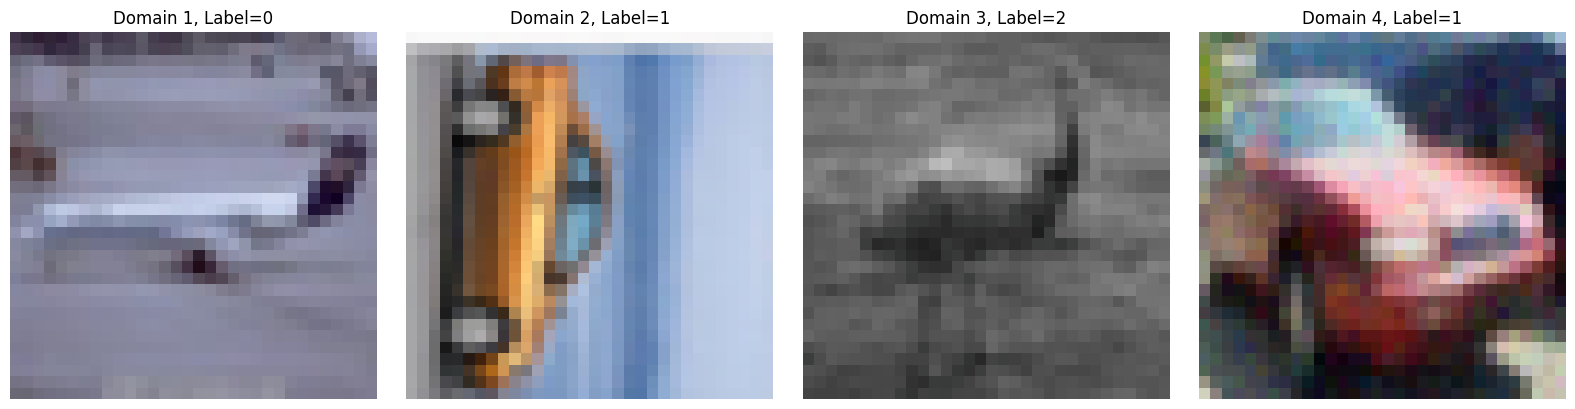

Max |R-G|: 5.960464477539063e-08
Max |G-B|: 5.960464477539063e-08
Max |R-B|: 5.960464477539063e-08


In [ ]:
if __name__ == "__main__":
  extract_path = download_cifar10()

  # Load raw arrays
  train_images, train_labels, test_images, test_labels = load_cifar10_raw(extract_path)
  print(f"Train set: {train_images.shape} | Test set: {test_images.shape}")

  # Save PNGs
  if not os.path.exists(PNG_DIR):
    save_pngs(train_images, train_labels, test_images, test_labels)
  else:
    print(f"PNGs already exist -> {PNG_DIR}")


  # Build all domain loaders
  all_loaders = build_all_domains(num_workers=0)
  print("All domain loaders ready.")

  #verifications of augmentation result
  show_one_example_per_domain(all_loaders, split="train")
  check_grayscale_domain(all_loaders)

Loaded splits -> train:35000 val:5000  test:10000


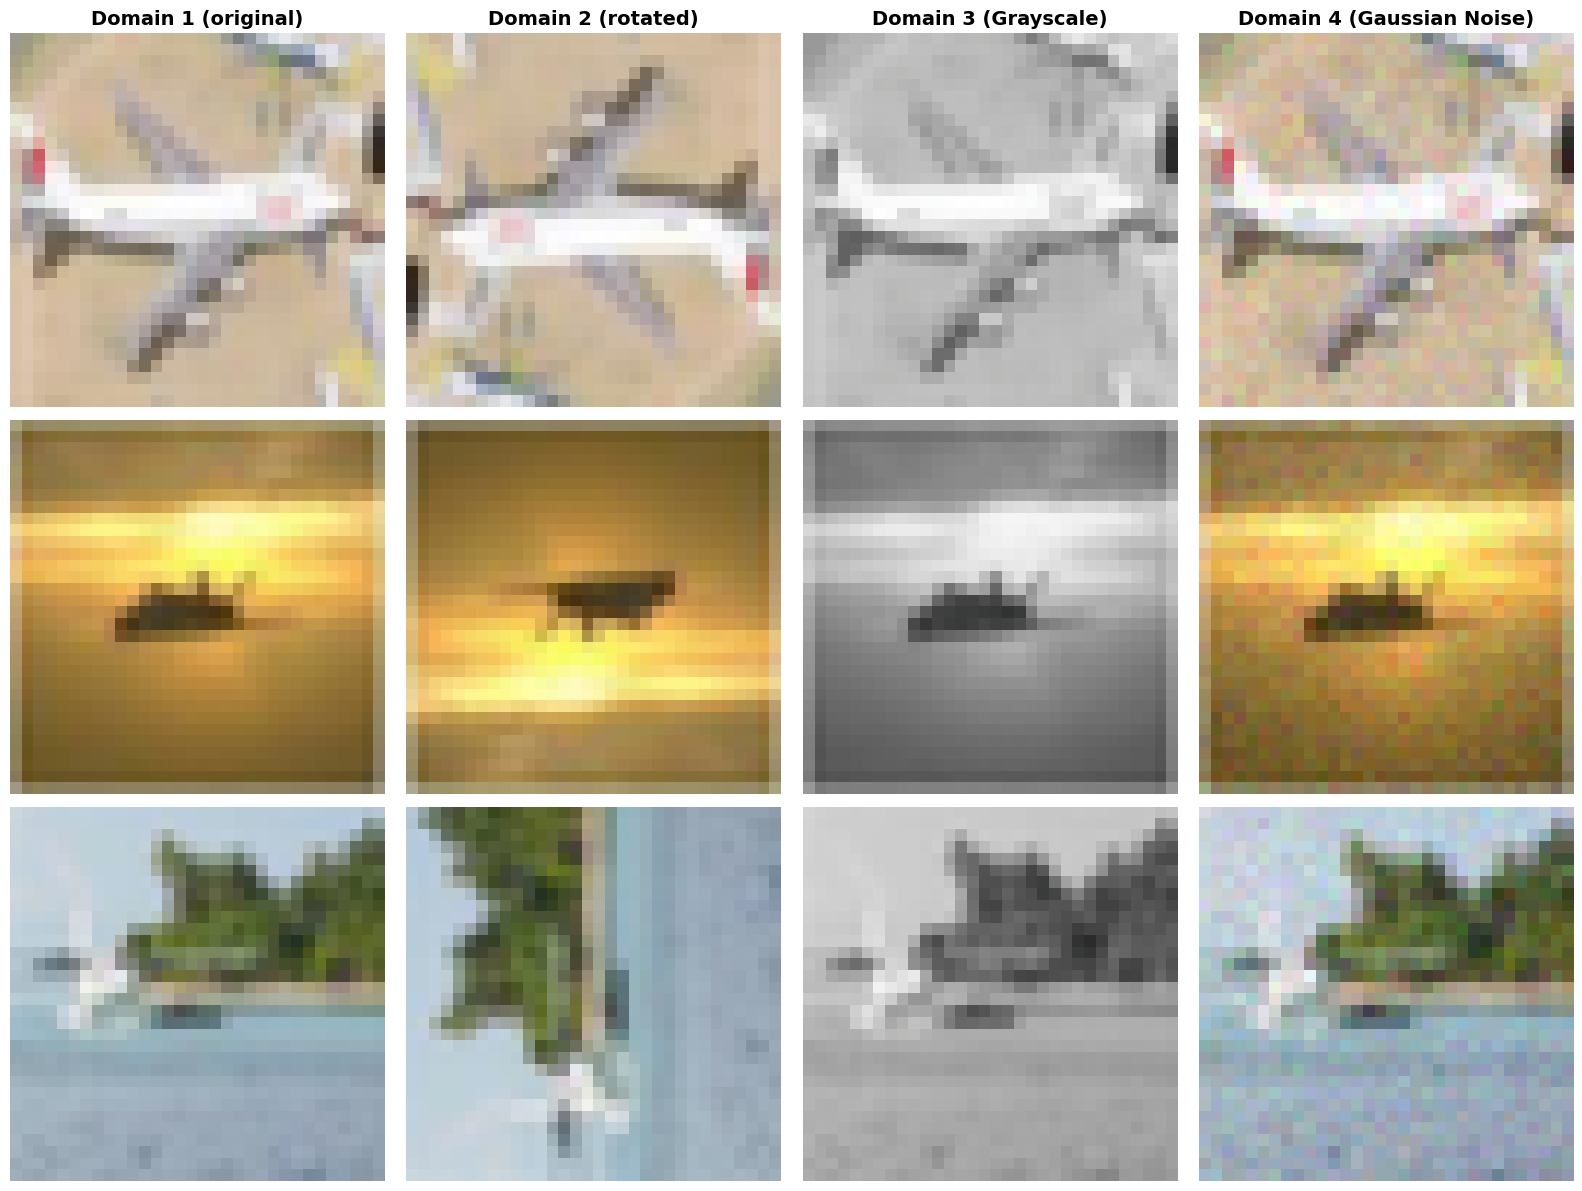

In [ ]:
def show_specific_comparisons(png_dir, indices=[0, 10, 20]):
  """
  Displays a grid where each row is the SAME image
  across different domains.
  """
  splits = load_splits(png_dir)
  train_samples = splits['train']

  domains = [1, 2, 3, 4]
  titles = ["Domain 1 (original)", "Domain 2 (rotated)", "Domain 3 (Grayscale)", "Domain 4 (Gaussian Noise)"]

  num_examples = len(indices)
  fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4 * num_examples))

  for i, idx in enumerate(indices):
    path, label = train_samples[idx]

    for j, domain in enumerate(domains):
      # Get transform for this domain
      transform = get_domain_transform(domain)

      # Load and transform the SAME physical file
      img = Image.open(path).convert("RGB")
      img_t = transform(img)

      # Unnormalize for visualization
      img_vis = unnormalize(img_t).clamp(0, 1)
      img_np = img_vis.permute(1, 2, 0).numpy()

      ax = axes[i, j] if num_examples > 1 else axes[j]
      ax.imshow(img_np)
      if i == 0:
        ax.set_title(titles[j], fontsize=14, fontweight='bold')
      ax.axis("off")

  plt.tight_layout()
  plt.show()

# Compare the same 3 images across all augmentations
show_specific_comparisons(PNG_DIR, indices=[100, 500, 1000])

In [ ]:
# all_loaders[domain]["train" | "val" | "test"]
all_loaders[1]["train"], all_loaders[3]["test"]

(<torch.utils.data.dataloader.DataLoader at 0x78da19ee89e0>,
 <torch.utils.data.dataloader.DataLoader at 0x78da19edb4a0>)

# [Office-Home](https://www.hemanthdv.org/OfficeHome-Dataset/)

## Setup
Download the dataset from
https://drive.google.com/file/d/0B81rNlvomiwed0V1YUxQdC1uOTg/view?resourcekey=0-2SNWq0CDAuWOBRRBL7ZZsw

Click the folder icon and upload the zip file

In [ ]:
import os
import shutil
import zipfile
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Download the zip from Google Drive and place it at this path before running
ZIP_PATH = "/content/OfficeHomeDataset_10072016.zip"
DATA_DIR = "/content/officehome_data"       # where zip is extracted
PNG_DIR = "/content/officehome_pngs"       # where split PNGs are saved
BATCH_SIZE = 64
SPLIT = (0.70, 0.10, 0.20)
SEED = 42
IMAGE_SIZE = 32

DOMAIN_FOLDERS = {
  1: "Art",
  2: "Clipart",
  3: "Product",
  4: "Real World"
}

# ImageNet normalization
NORMALIZE = transforms.Normalize(
  mean=[0.485, 0.456, 0.406],
  std =[0.229, 0.224, 0.225]
)

def extract_officehome(zip_path: str = ZIP_PATH,
                       data_dir: str = DATA_DIR) -> str:
  # Extract Zip
  os.makedirs(data_dir, exist_ok=True)

  if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Download from Office-Home dataset page and upload to Colab")

  print("Extracting Office-Home dataset ...")
  with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(data_dir)
  print("Extraction complete.")

  # Find root folder
  extracted = [
      os.path.join(data_dir, d)
      for d in os.listdir(data_dir)
      if os.path.isdir(os.path.join(data_dir, d))
  ]
  root = extracted[0]
  print(f"Dataset root: {root}")
  return root

def get_classes(dataset_root: str) -> list:
  """
  Returns a list of all classes in the dataset.
  """
  domain_path = os.path.join(dataset_root, "Art")
  classes = sorted([
      d for d in os.listdir(domain_path)
      if os.path.isdir(os.path.join(domain_path, d))
  ])
  print(f"Found {len(classes)} classes.")
  return classes

Save PNGs into train/val/test per domain

In [ ]:
def save_pngs(dataset_root: str, classes: list, png_dir: str = PNG_DIR, split: tuple = SPLIT, seed: int = SEED, image_size: int = IMAGE_SIZE) -> None:
  rng = np.random.default_rng(seed)

  for domain_id, domain_name in DOMAIN_FOLDERS.items():
    print(f"\nProcessing Domain {domain_id}: {domain_name} ...")
    train_count, val_count, test_count = 0, 0, 0

    for lbl, cls in enumerate(classes):
      src_dir = os.path.join(dataset_root, domain_name, cls)

      if not os.path.exists(src_dir):
        print(f"Warning: {src_dir} does not exist.")
        continue

      files = sorted([
          os.path.join(src_dir, f)
          for f in os.listdir(src_dir)
          if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
      ])
      files = np.array(files)
      rng.shuffle(files)

      n = len(files)
      n_tr = int(n * split[0])
      n_val = int(n * split[1])

      split_map = {
          "train": files[:n_tr],
          "val": files[n_tr:n_tr + n_val],
          "test": files[n_tr + n_val:]
      }

      for split_name, split_files in split_map.items():
        out_dir = os.path.join(png_dir, domain_name, split_name, cls)
        os.makedirs(out_dir, exist_ok=True)

        for i, fpath in enumerate(split_files):
          try:
            img = Image.open(fpath).convert("RGB")
            img = img.resize((image_size, image_size), Image.BILINEAR)
            img.save(os.path.join(out_dir, f"{i:05d}.png"))
          except Exception as e:
            print(f" Skipping {fpath}: {e}")

      train_count += len(split_map["train"])
      val_count += len(split_map["val"])
      test_count += len(split_map["test"])

  print(f" train:{train_count} val:{val_count} test:{test_count}")

# Load splits from folders
def load_splits(domain_id: int, classes: list, png_dir: str = PNG_DIR) -> dict:
  domain_name = DOMAIN_FOLDERS[domain_id]
  splits = {"train": [], "val": [], "test": []}

  for split_name in ["train", "val", "test"]:
    for lbl, cls in enumerate(classes):
      cls_dir = os.path.join(png_dir, domain_name, split_name, cls)
      if not os.path.exists(cls_dir):
        continue
      files = sorted([
          os.path.join(cls_dir, f)
          for f in os.listdir(cls_dir)
          if f.endswith(".png")
      ])
      splits[split_name].extend([(p, lbl) for p in files])

  print(f"Domain {domain_id} ({domain_name}) splits -> "
        f"train:{len(splits['train'])} "
        f"val:{len(splits['val'])}  "
        f"test:{len(splits['test'])}")
  return splits


Domain Transform + Dataset

In [ ]:
def get_transform() -> transforms.Compose:
  return transforms.Compose([
    transforms.ToTensor(),
    NORMALIZE,
  ])

In [ ]:
class OfficeHomeDomainDataset(Dataset):
  def __init__(self, samples: list):
    self.samples = samples
    self.transform = get_transform()

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path, label = self.samples[idx]
    img = Image.open(path).convert("RGB")
    return self.transform(img), label

Data Loader + Build all domains

In [ ]:
def build_dataloaders(splits: dict, batch_size: int = BATCH_SIZE, num_workers: int = 2) -> dict:
  loaders = {}
  for split_name in ["train", "val", "test"]:
    dataset = OfficeHomeDomainDataset(splits[split_name])
    loaders[split_name] = DataLoader(
        dataset, batch_size=batch_size, shuffle=(split_name == "train"), num_workers=num_workers, pin_memory=True
    )
  return loaders

def build_all_domains(classes: list, png_dir: str = PNG_DIR, batch_size: int = BATCH_SIZE, num_workers: int = 2) -> dict:
  all_loaders = {}
  for domain_id in range(1, 5):
    print(f"Building Domain {domain_id} loaders ...")
    splits = load_splits(domain_id, classes, png_dir=png_dir)
    all_loaders[domain_id] = build_dataloaders(
        splits, batch_size=batch_size, num_workers=num_workers
    )
  return all_loaders

In [ ]:
if __name__ == "__main__":
  dataset_root = extract_officehome()

  classes = get_classes(dataset_root)
  print(f"Classes: {classes}")

  if not os.path.exists(PNG_DIR):
    save_pngs(dataset_root, classes)
  else:
    print(f"PNGs already exist -> {PNG_DIR}")

  all_loaders = build_all_domains(classes, num_workers=0)
  print("All domain loaders ready.")

Extracting Office-Home dataset ...
Extraction complete.
Dataset root: /content/officehome_data/OfficeHomeDataset_10072016
Found 65 classes.
Classes: ['Alarm_Clock', 'Backpack', 'Batteries', 'Bed', 'Bike', 'Bottle', 'Bucket', 'Calculator', 'Calendar', 'Candles', 'Chair', 'Clipboards', 'Computer', 'Couch', 'Curtains', 'Desk_Lamp', 'Drill', 'Eraser', 'Exit_Sign', 'Fan', 'File_Cabinet', 'Flipflops', 'Flowers', 'Folder', 'Fork', 'Glasses', 'Hammer', 'Helmet', 'Kettle', 'Keyboard', 'Knives', 'Lamp_Shade', 'Laptop', 'Marker', 'Monitor', 'Mop', 'Mouse', 'Mug', 'Notebook', 'Oven', 'Pan', 'Paper_Clip', 'Pen', 'Pencil', 'Postit_Notes', 'Printer', 'Push_Pin', 'Radio', 'Refrigerator', 'Ruler', 'Scissors', 'Screwdriver', 'Shelf', 'Sink', 'Sneakers', 'Soda', 'Speaker', 'Spoon', 'TV', 'Table', 'Telephone', 'ToothBrush', 'Toys', 'Trash_Can', 'Webcam']
PNGs already exist -> /content/officehome_pngs
Building Domain 1 loaders ...
Domain 1 (Art) splits -> train:1677 val:218  test:532
Building Domain 2 load

# [DomainNet](http://ai.bu.edu/DomainNet/)